<a href="https://colab.research.google.com/github/sjkim0520/Mechanical_Project/blob/main/Step1__%EC%9D%B4%EB%A1%A0%EA%B3%BC_%ED%9A%8C%EA%B7%80%EB%AA%A8%EB%8D%B8_%EA%B8%B0%EC%B4%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Step1. 반응표면분석법(RSM) 이론 &amp; 회귀 모델 기초

**프로젝트 3. HBM 구리(Cu) 하이브리드 본딩 CMP 공정 조건 RSM 최적화**

이 노트북에서는 본 프로젝트의 핵심 도구인 **반응표면분석법(Response Surface Methodology, RSM)**의 수학적 배경을 아주 기초부터 다집니다.
CMP(Chemical Mechanical Polishing, 화학기계연마) 공정 데이터는 3~4일차에 만들 것이고, 오늘은 **"왜 2차식으로 공정을 모델링하는가"**, **"최소제곱법(Least Squares)으로 계수를 어떻게 구하는가"**를 손으로 코드를 짜며 이해하는 것이 목표입니다.


## 1. CMP 공정과 RSM이 왜 필요한가

HBM(High Bandwidth Memory)의 하이브리드 본딩에서는 Cu 패드와 SiO₂(또는 SiCN) 절연막을 동시에 연마해 완전히 평탄한 표면을 만들어야 합니다.
그런데 Cu가 SiO₂보다 훨씬 무르기 때문에 Cu 부분이 더 많이 깎여 오목하게 파이는 **디싱(Dishing)** 현상이 발생합니다. 디싱이 크면 본딩 후 접촉 불량, 전기적 저항 증가, 공동(void) 등이 생겨 신뢰성이 떨어집니다.
(참고: ScienceDirect, *"Mitigation of Cu dishing in chemical mechanical polishing using micro-structured pads"*, 2025 — 디싱은 Cu가 SiO₂보다 연질이라 더 빨리 제거되기 때문에 발생하며, 하이브리드 본딩에서는 이를 최소화하는 것이 필수적이라고 설명합니다.)

CMP 공정에는 압력(Pressure), 회전 속도(Velocity/RPM), 슬러리 유량, 슬러리 pH, 패드 컨디셔닝 상태 등 **여러 변수가 동시에** 반응(제거율 MRR, 디싱 깊이, 표면조도 Ra)에 영향을 줍니다.
한 번에 변수 하나씩만 바꿔가며 실험하면(One-Factor-At-a-Time) 변수 간 **상호작용(interaction)**을 놓치고, 실험 횟수도 비효율적으로 많아집니다.

**RSM**은 적은 수의 실험으로
1. 여러 공정변수와 반응 사이의 관계를 다항식(주로 2차식)으로 근사하고,
2. 그 근사식(회귀모델) 위에서 수학적으로 최적점을 찾는 통계적 실험계획법입니다.

RSM은 1951년 Box와 Wilson이 화학 공정 최적화를 위해 처음 제안했고, 지금은 반도체 CMP, 사출성형, 식품공학 등 산업 전반에서 표준적으로 쓰입니다.


## 2. Preston 방정식 — CMP 제거율(MRR)의 출발점

CMP 분야에서 가장 유명한 기초 물리식은 1927년 F. W. Preston이 유리 연마 공정을 설명하며 제안한 **Preston 방정식**입니다.

$$
MRR = K_p \cdot P \cdot V
$$

- $MRR$ : 재료 제거율 (Material Removal Rate, 예: nm/min)
- $P$ : 패드가 웨이퍼를 누르는 압력 (Pressure)
- $V$ : 패드와 웨이퍼 사이의 상대 속도 (Velocity, 회전 속도에 비례)
- $K_p$ : Preston 계수 — 슬러리 화학, 패드 재질, 표면 상태 등 나머지 모든 요인을 하나로 묶은 실험적 상수

즉, **제거율은 압력과 속도의 곱에 비례한다**는 아주 단순한 선형 관계식입니다.
하지만 실제 공정에서는 $K_p$가 슬러리 pH, 유량, 온도 등에 따라 달라지고, 압력이 너무 커지면 오히려 디싱이 급격히 증가하는 **비선형(non-linear) 거동**이 나타납니다.
그래서 우리는 Preston 방정식을 "1차 근사"로 삼되, 실제 반응표면은 **2차 다항식**으로 확장해서 모델링할 것입니다.


## 3. 반응표면모델(RSM)의 수학적 형태

변수가 $k$개 있다고 하면, RSM에서 가장 널리 쓰이는 **2차(quadratic) 모델**은 다음과 같습니다.

$$
y = \beta_0 + \sum_{i=1}^{k}\beta_i x_i + \sum_{i=1}^{k}\beta_{ii}x_i^2 + \sum_{i<j}\beta_{ij}x_i x_j + \varepsilon
$$

각 항의 의미:
- $\beta_0$ : 절편(intercept) — 모든 변수가 기준점(0, 중심점)일 때의 반응값
- $\beta_i x_i$ : **주효과(main effect)** — 변수 $x_i$가 반응에 주는 선형적 영향
- $\beta_{ii}x_i^2$ : **2차 효과(quadratic effect)** — 반응이 특정 지점에서 꺾이는 곡률(최댓값/최솟값)을 표현
- $\beta_{ij}x_i x_j$ : **교호작용(interaction)** — 두 변수가 "함께" 반응에 주는 영향 (한 변수의 효과가 다른 변수 수준에 따라 달라짐)
- $\varepsilon$ : 실험 오차(잡음)

예를 들어 변수가 압력($x_1$), 속도($x_2$), 슬러리 유량($x_3$) 3개라면 모델은 다음처럼 10개의 계수($\beta_0, \beta_1, \beta_2, \beta_3, \beta_{11}, \beta_{22}, \beta_{33}, \beta_{12}, \beta_{13}, \beta_{23}$)를 가진 식이 됩니다.

이 계수들을 **실험 데이터로부터 추정**하는 방법이 다음 절의 최소제곱법입니다.


## 4. 최소제곱법(Least Squares)으로 계수 구하기

관측치가 $n$개 있고 계수가 $p$개인 선형모델을 행렬로 쓰면

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

- $\mathbf{y}$ : $n \times 1$ 관측 반응 벡터
- $\mathbf{X}$ : $n \times p$ **설계행렬(design matrix)** — 각 행은 하나의 실험조건에서 $[1, x_1, x_2, x_1^2, x_1x_2, \dots]$처럼 모델의 각 항 값을 나열한 것
- $\boldsymbol{\beta}$ : $p \times 1$ 우리가 구하고 싶은 계수 벡터

오차 제곱합 $S(\beta) = (\mathbf{y}-\mathbf{X}\beta)^T(\mathbf{y}-\mathbf{X}\beta)$ 을 최소화하는 $\beta$는 미분해서 0으로 놓으면 다음 **정규방정식(normal equation)**의 해로 구해집니다.

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

아래 실습에서 이 식을 **직접 코드로 구현**해보고, 이후 4일차부터는 `scikit-learn`이 이를 자동으로 해주는 것을 확인합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

### 실습 1. 1변수 2차 모델을 정규방정식으로 직접 풀어보기

가상의 CMP 실험에서, 압력 $x$ (0~7 psi)에 따라 제거율(MRR, 임의단위)이 아래와 같은 "숨겨진 진짜 관계"를 가진다고 가정합니다.

$$
y = 3 + 12x - 1.1x^2 + \varepsilon
$$

우리는 이 진짜 계수를 모른다고 가정하고, **노이즈가 섞인 관측 데이터만 가지고** 정규방정식으로 계수를 추정해봅니다.


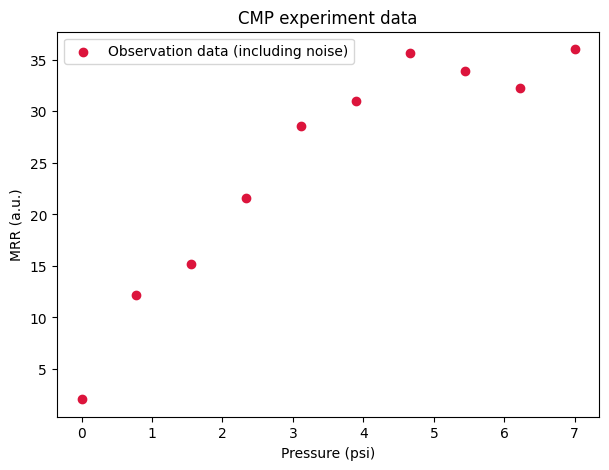

In [4]:
# 압력(x) 10개 지점에서 실험했다고 가정
x = np.linspace(0, 7, 10)

# TODO 1: 관계식 y = 3 + 12*x - 1.1*x^2 에 노이즈를 더해 y_obs를 만드세요.
#         노이즈는 평균 0, 표준편차 2인 정규분포로 생성 (np.random.normal 사용)
noise = np.random.normal(loc=0.0, scale=2.0, size=x.shape)
y_obs = 3 + 12 * x - 1.1 * x**2 + noise

plt.scatter(x, y_obs, color='crimson', label='Observation data (including noise)')
plt.xlabel('Pressure (psi)')
plt.ylabel('MRR (a.u.)')
plt.legend()
plt.title('CMP experiment data')
plt.show()

In [5]:
# TODO 2: 설계행렬 X를 만드세요.
#         2차 모델이므로 각 행은 [1, x_i, x_i^2] 형태가 되어야 합니다.
#         힌트: np.column_stack([np.ones_like(x), x, x**2]) 형태를 활용하세요.
X = np.column_stack([np.ones_like(x), x, x**2])

print("설계행렬 X의 크기:", X.shape)   # (10, 3) 이 나와야 정상입니다
print(X[:3])

설계행렬 X의 크기: (10, 3)
[[1.         0.         0.        ]
 [1.         0.77777778 0.60493827]
 [1.         1.55555556 2.41975309]]


In [6]:
# TODO 3: 정규방정식 beta_hat = (X^T X)^-1 X^T y 를 numpy로 직접 구현하세요.
#         numpy.linalg.inv 와 행렬곱(@ 연산자)을 사용합니다.
XtX = X.T @X
XtY = X.T @y_obs
beta_hat = np.linalg.inv(XtX) @XtY

print("추정된 계수 [b0, b1, b2]:", beta_hat)
print("진짜 계수는 [3, 12, -1.1] 였습니다. 노이즈 때문에 정확히 일치하지는 않지만 비슷해야 합니다.")


추정된 계수 [b0, b1, b2]: [ 2.4513291  10.76571087 -0.88694769]
진짜 계수는 [3, 12, -1.1] 였습니다. 노이즈 때문에 정확히 일치하지는 않지만 비슷해야 합니다.


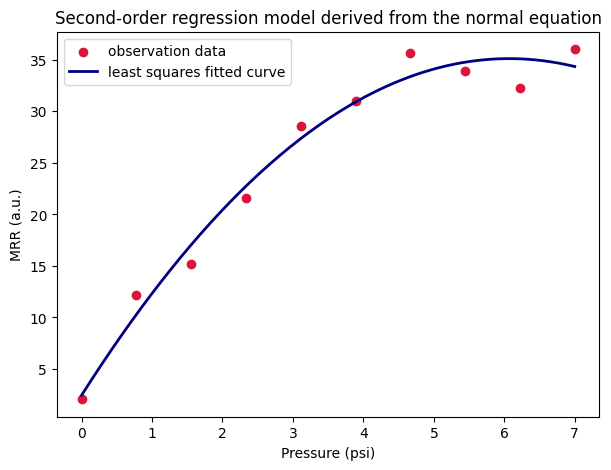

In [10]:
# 적합된 곡선을 그려서 확인합니다.
x_fine = np.linspace(0, 7, 200)

# TODO 4: 추정한 beta_hat을 이용해 x_fine에 대한 예측값 y_fit을 계산하세요.
#         y_fit = b0 + b1*x_fine + b2*x_fine^2
y_fit = beta_hat[0]+beta_hat[1]*x_fine+beta_hat[2]*x_fine**2

plt.scatter(x, y_obs, color='crimson', label='observation data')
plt.plot(x_fine, y_fit, color='navy', linewidth=2, label='least squares fitted curve')
plt.xlabel('Pressure (psi)')
plt.ylabel('MRR (a.u.)')
plt.legend()
plt.title('Second-order regression model derived from the normal equation')
plt.show()


### 실습 2. 변수가 2개일 때 반응표면(Response Surface) 그려보기

이번엔 압력 $x_1$과 속도 $x_2$ 두 변수가 있는 2차 모델을 시각화해봅니다.

$$
y = 50 + 8x_1 + 5x_2 - 0.6x_1^2 - 0.4x_2^2 + 0.3x_1x_2
$$

이 식이 바로 **반응표면(response surface)**입니다. 3~4일차에는 이런 계수를 실제 데이터로부터 추정하게 됩니다.


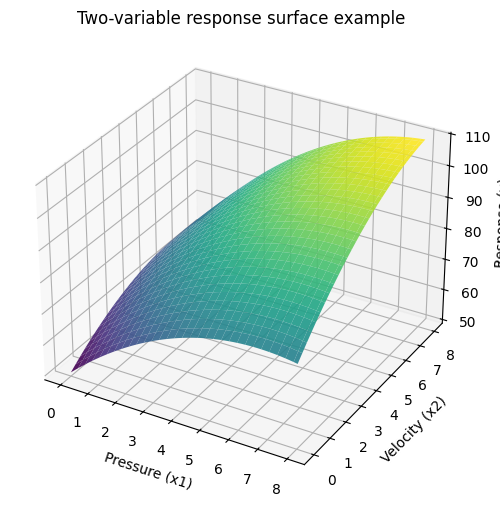

In [12]:
x1 = np.linspace(0, 8, 60)
x2 = np.linspace(0, 8, 60)
X1, X2 = np.meshgrid(x1, x2)

# TODO 5: 위 수식을 그대로 코드로 옮겨 Y를 계산하세요. (X1, X2는 이미 meshgrid로 만들어져 있습니다)
Y = 50+8*X1+5*X2-0.6*X1**2-0.4*X2**2+0.3*X1*X2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Y, cmap='viridis', alpha=0.9)
ax.set_xlabel('Pressure (x1)')
ax.set_ylabel('Velocity (x2)')
ax.set_zlabel('Response (y)')
ax.set_title('Two-variable response surface example')
plt.show()


## 5. 오늘의 정리 &amp; 생각해볼 질문

1. 위 3D 그래프에서 봉우리(최댓값)가 생기는 이유는 어떤 계수(항) 때문일까요? ($\beta_{ii}$의 부호와 관련이 있습니다)
2. Preston 방정식은 1차식인데, 왜 실제 CMP 공정은 2차식으로 모델링해야 더 잘 맞을까요? (힌트: 압력이 너무 세지면 어떤 일이 일어날지 생각해보세요)
3. 만약 $\beta_{12}$ (교호작용 계수)가 0이라면 반응표면의 모양은 어떻게 달라질까요? 위 코드에서 `0.3 * X1 * X2` 항을 지우고 다시 그려서 비교해보세요.

다음 노트북(Day 3~4)에서는 이 개념을 이용해 **가상의 CMP 실험 데이터셋(CCD 설계)**을 직접 만들고, `scikit-learn`으로 2차 회귀모델을 자동으로 적합해봅니다.
